# 🧪 Lab: Training Transformers: Encoder–Decoder vs Decoder-Only
**Agentic AI · Lab notebook** (use it together with the lab manual)

In this lab you build two transformers from their parts, train both on **your own personal task** generated from your student ID, and compare them head to head.

| Symbol | Meaning |
|---|---|
| 🎯 **TODO** | You write code here (usually 1–6 lines). Replace every `...` |
| ✅ **Check** | Run the test cell right after a TODO. Don't move on until it prints ✅ |
| 🤔 **Think** | Predict before you run. Write the prediction in your report notes |
| 🧨 **Experiment** | Break something on purpose and explain what happens (full path) |
| ⏱ | Rough time for the part |

**Before you start:** *Runtime → Change runtime type → T4 GPU*. A CPU also works; the notebook automatically trains for fewer steps.

## Part 0 · Setup and your personal task ⏱ 10 min

In [1]:
import hashlib, re, math, random, time, json, string, datetime
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
ON_GPU = device == "cuda"
print("device:", device, "| torch", torch.__version__)

device: cuda | torch 2.11.0+cu130


### 🎯 Enter your student ID
Your ID decides your **output date format**, which **input formats are hidden from training**, and your **random seed**. Everyone gets a different task, so your numbers, plots and explanations are your own.

In [2]:
STUDENT_ID = "23K-0594"     # e.g. "22K-4567"  <-- change this to YOUR ID
assert STUDENT_ID != "YOUR-ID-HERE", "Please enter your own student ID above."

The next cell is the task generator and the character tokenizer. You don't need to change it, but skim it: this is how your data is made.

In [3]:
# ---------------- personal task generator ----------------
ORDERS = ["YMD", "DMY", "MDY", "YDM", "DYM", "MYD"]
SEPS = ["-", "/", ".", "_"]
MONTH_STYLES = ["number", "abbr", "roman"]
MONTHS = ["January", "February", "March", "April", "May", "June", "July", "August",
          "September", "October", "November", "December"]
ROMAN = ["I", "II", "III", "IV", "V", "VI", "VII", "VIII", "IX", "X", "XI", "XII"]
WEEKDAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

def _all_input_combos():
    """Every way a human might write a date in this lab: 36 input formats."""
    combos = []
    for mform in ["full", "short", "num"]:          # September / Sep / 09
        for order in ["DMY", "MDY"]:                # 25 Sep 2026 / Sep 25, 2026
            for dform in ["plain", "ordinal"]:      # 25 / 25th
                for yform in ["4", "2"]:            # 2026 / 26
                    for wd in [False, True]:        # optional weekday prefix
                        if mform == "num" and (order == "MDY" or dform == "ordinal"):
                            continue
                        combos.append((mform, order, dform, yform, wd))
    return combos
INPUT_COMBOS = _all_input_combos()

def student_config(student_id):
    """Your personal task, derived deterministically from your student ID."""
    sid = re.sub(r"[^A-Za-z0-9]", "", student_id).upper()
    assert len(sid) >= 4, "Please enter your full student ID"
    h = int(hashlib.sha256(("transformer-lab-v1:" + sid).encode()).hexdigest(), 16)
    order = ORDERS[h % 6]; h //= 6
    sep = SEPS[h % 4]; h //= 4
    month_style = MONTH_STYLES[h % 3]; h //= 3
    rng = random.Random(h)
    text_combos = [i for i, c in enumerate(INPUT_COMBOS) if c[0] != "num"]
    heldout = sorted(rng.sample(text_combos, 4))
    return {"student_id": sid, "order": order, "sep": sep, "month_style": month_style,
            "heldout_combos": heldout, "seed": h % (2**31 - 1)}

def format_output(d, m, y, cfg):
    """The target string in YOUR personal output format."""
    month = {"number": f"{m:02d}", "abbr": MONTHS[m - 1][:3].upper(), "roman": ROMAN[m - 1]}[cfg["month_style"]]
    parts = {"Y": f"{y:04d}", "M": month, "D": f"{d:02d}"}
    return cfg["sep"].join(parts[c] for c in cfg["order"])

def describe_combo(i):
    mform, order, dform, yform, wd = INPUT_COMBOS[i]
    return (f"{'weekday + ' if wd else ''}{ {'full': 'full month', 'short': 'short month', 'num': 'numeric'}[mform]}, "
            f"{order}, {'ordinal day' if dform == 'ordinal' else 'plain day'}, {yform}-digit year")

def _ordinal(d):
    suf = "th" if 11 <= d % 100 <= 13 else {1: "st", 2: "nd", 3: "rd"}.get(d % 10, "th")
    return f"{d}{suf}"

def render_input(d, m, y, combo, rng):
    """A messy, human-style rendering of the date."""
    mform, order, dform, yform, wd = combo
    year = f"{y}" if yform == "4" else f"{y % 100:02d}"
    if mform == "num":
        s = rng.choice("/.-").join([f"{d:02d}", f"{m:02d}", year])
    else:
        if mform == "full":
            mon = MONTHS[m - 1]
        else:
            mon = MONTHS[m - 1][:4] if (m == 9 and rng.random() < 0.5) else MONTHS[m - 1][:3]
        day = _ordinal(d) if dform == "ordinal" else str(d)
        s = f"{day} {mon} {year}" if order == "DMY" else f"{mon} {day}, {year}"
    if wd:
        w = WEEKDAYS[datetime.date(y, m, d).weekday()]
        s = (w if rng.random() < 0.5 else w[:3]) + ", " + s
    case = rng.random()
    return s.lower() if case < 0.3 else (s.upper() if case < 0.4 else s)

def random_date(rng):
    start, end = datetime.date(1950, 1, 1).toordinal(), datetime.date(2049, 12, 31).toordinal()
    dt = datetime.date.fromordinal(rng.randint(start, end))
    return dt.day, dt.month, dt.year

def make_dataset(cfg, n, split, rng):
    """split='train': every input format except yours held out; split='heldout': only held-out formats."""
    allowed = [i for i in range(len(INPUT_COMBOS)) if (i in cfg["heldout_combos"]) == (split == "heldout")]
    pairs = []
    for _ in range(n):
        d, m, y = random_date(rng)
        combo = INPUT_COMBOS[rng.choice(allowed)]
        pairs.append((render_input(d, m, y, combo, rng), format_output(d, m, y, cfg)))
    return pairs

def build_data(cfg, n_train=40000, n_val=2000, n_test=1000):
    rng = random.Random(cfg["seed"])
    train = make_dataset(cfg, n_train, "train", rng)
    val = make_dataset(cfg, n_val, "train", rng)
    heldout = make_dataset(cfg, n_test, "heldout", rng)
    return train, val, heldout

def fingerprint(cfg, train):
    blob = json.dumps([cfg["order"], cfg["sep"], cfg["month_style"], cfg["heldout_combos"], train[:500]])
    return hashlib.sha256(blob.encode()).hexdigest()[:12]

# ---------------- character tokenizer ----------------
PAD, BOS, EOS, SEP = 0, 1, 2, 3
SPECIALS = ["<pad>", "<bos>", "<eos>", "<sep>"]
CHARS = sorted(set(string.ascii_letters + string.digits + " ,'/.-_"))
itos = SPECIALS + CHARS
stoi = {c: i for i, c in enumerate(itos)}
V = len(itos)

def encode(s):
    return [stoi[c] for c in s]

def decode(ids):
    out = []
    for i in ids:
        if i == EOS:
            break
        if i >= len(SPECIALS):
            out.append(itos[i])
    return "".join(out)

In [4]:
cfg = student_config(STUDENT_ID)
train_pairs, val_pairs, heldout_pairs = build_data(cfg)
FP = fingerprint(cfg, train_pairs)
random.seed(cfg["seed"]); torch.manual_seed(cfg["seed"])

print("=" * 66)
print(f" Student ID     : {cfg['student_id']}")
print(f" Output format  : order={cfg['order']}   separator='{cfg['sep']}'   month={cfg['month_style']}")
print(f" Example        : '25 September 2026'  ->  '{format_output(25, 9, 2026, cfg)}'")
print(f" Fingerprint    : {FP}        <-- copy this into your report")
print(" Held-out input formats (never seen in training):")
for i in cfg["heldout_combos"]:
    print(f"   #{i:2d}  {describe_combo(i)}")
print("=" * 66)
print(f"train {len(train_pairs):,} | val {len(val_pairs):,} | held-out test {len(heldout_pairs):,} | vocab {V}")
print("\nTraining examples:")
for s, t in train_pairs[:8]:
    print(f"   {s!r:40s} -> {t!r}")
print("\nHELD-OUT examples (formats the models will never train on):")
for s, t in heldout_pairs[:4]:
    print(f"   {s!r:40s} -> {t!r}")

 Student ID     : 23K0594
 Output format  : order=YMD   separator='.'   month=abbr
 Example        : '25 September 2026'  ->  '2026.SEP.25'
 Fingerprint    : 53ddece0fd2f        <-- copy this into your report
 Held-out input formats (never seen in training):
   # 1  weekday + full month, DMY, plain day, 4-digit year
   # 2  full month, DMY, plain day, 2-digit year
   # 6  full month, DMY, ordinal day, 2-digit year
   #16  short month, DMY, plain day, 4-digit year
train 40,000 | val 2,000 | held-out test 1,000 | vocab 73

Training examples:
   '22 March 1964'                          -> '1964.MAR.22'
   '1 Aug 99'                               -> '1999.AUG.01'
   'may 28th, 2014'                         -> '2014.MAY.28'
   'sunday, jul 17, 1977'                   -> '1977.JUL.17'
   'Thu, 15th Jul 71'                       -> '1971.JUL.15'
   'MAR 17TH, 2021'                         -> '2021.MAR.17'
   'December 18, 1956'                      -> '1956.DEC.18'
   'May 19th, 2034'        

🤔 **Think:** Look at your output format.
1. Which field (year, month, day) do you expect to be *hardest* for a model to produce, and why?

- year as some inputs only give a 2-digit year, like 99 or 71, and the model has to work out the full year on its own. It has to learn that 99 means 1999 and 26 means 2026. Nobody tells it the rule (50-99 means 1900s, 00-49 means 2000s). It can only learn it by seeing thousands of examples


2. When the model writes the **month** of your output, which input characters must it look at?

- It has to look at the first three letters of the month name in the input. Three letters are enough to tell every month apart. The third letter matters most, because mar and may, and jun and jul, only differ there.

## Warm-up · Scaled dot-product attention ⏱ 10 min
$$\mathrm{Attention}(Q,K,V)=\mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$
Masks in this lab are **boolean**: `True` means *allowed to attend*. Blocked positions get a score of $-\infty$ before the softmax, so they receive exactly zero weight.

In [5]:
MAX_SRC, MAX_TGT = 40, 16

def pad_to(ids, L):
    return ids[:L] + [PAD] * (L - len(ids))

In [6]:
# ---------- Warm-up: attention ----------
def scaled_dot_product_attention(q, k, v, mask=None):
    """q: (B,h,Tq,dk)  k,v: (B,h,Tk,dk)
    mask: bool, broadcastable to (B,h,Tq,Tk); True = may attend.
    Returns (output (B,h,Tq,dk), weights (B,h,Tq,Tk))."""
    # 🎯 TODO 1: scores = QK^T / sqrt(dk); masked positions -> -inf; softmax over the LAST dim
    #    Hints: k.transpose(-2, -1), math.sqrt(q.size(-1)), scores.masked_fill(~mask, float("-inf"))
    scores = q @ k.transpose(-2, -1) / math.sqrt(q.size(-1))
    if mask is not None:
        scores = scores.masked_fill(~mask, float("-inf"))
    weights =  F.softmax(scores, dim=-1)
    return weights @ v, weights

In [7]:
# ✅ Check 1
q, k, v = torch.randn(2, 4, 5, 8), torch.randn(2, 4, 7, 8), torch.randn(2, 4, 7, 8)
m = torch.rand(2, 1, 5, 7) > 0.3; m[..., 0] = True
out, w = scaled_dot_product_attention(q, k, v, m)
ref = F.scaled_dot_product_attention(q, k, v, attn_mask=m)
assert out.shape == (2, 4, 5, 8) and w.shape == (2, 4, 5, 7), "wrong output shapes"
assert torch.allclose(w.sum(-1), torch.ones(2, 4, 5), atol=1e-5), "weights must sum to 1 over the keys"
assert (w[~m.expand_as(w)] == 0).all(), "masked positions must get exactly 0 weight"
assert torch.allclose(out, ref, atol=1e-5), "does not match PyTorch's reference implementation"
print("✅ Check 1 passed: your attention matches PyTorch's own")

✅ Check 1 passed: your attention matches PyTorch's own


Multi-head attention and the feed-forward network are provided. Note the two inputs `x_q` and `x_kv`: **self-attention passes the same tensor twice; cross-attention passes two different tensors.**

In [8]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d, n_head):
        super().__init__()
        self.h, self.dk = n_head, d // n_head
        self.wq, self.wk, self.wv, self.wo = (nn.Linear(d, d) for _ in range(4))
        self.last_weights = None                      # kept for plotting
    def forward(self, x_q, x_kv, mask=None):
        B, Tq, D = x_q.shape
        Tk = x_kv.size(1)
        q = self.wq(x_q).view(B, Tq, self.h, self.dk).transpose(1, 2)
        k = self.wk(x_kv).view(B, Tk, self.h, self.dk).transpose(1, 2)
        v = self.wv(x_kv).view(B, Tk, self.h, self.dk).transpose(1, 2)
        out, w = scaled_dot_product_attention(q, k, v, mask)
        self.last_weights = w.detach()
        return self.wo(out.transpose(1, 2).reshape(B, Tq, D))

def feed_forward(d):
    return nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d))

## Part A · Encoder–Decoder ⏱ 35 min
### A1–A2. The two masks
* **Padding mask:** inputs are padded to a fixed length with `<pad>` (id 0). No position should attend *to* padding.
* **Causal mask:** when the decoder predicts output character *i*, it may only see output characters ≤ *i*.

In [9]:
# ---------- masks ----------
def make_padding_mask(ids):
    """ids (B,T) -> bool (B,1,1,T): True where the token is NOT padding."""
    # 🎯 TODO 2 (one line). Hint: compare with PAD, then index with [:, None, None, :]
    return (ids != PAD)[:, None, None, :]

def make_causal_mask(T, device=None):
    """-> bool (1,1,T,T): position i may attend to position j only if j <= i."""
    # 🎯 TODO 3 (one line). Hint: torch.tril(torch.ones(T, T, dtype=torch.bool, device=device)), then [None, None]
    return torch.tril(torch.ones(T, T, dtype=torch.bool, device=device))[None, None]

✅ Checks 2 & 3 passed


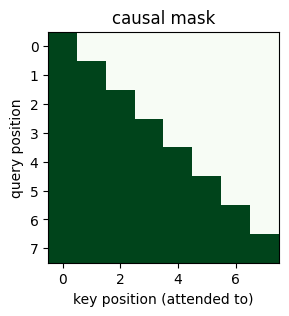

In [10]:
# ✅ Checks 2 & 3
pm = make_padding_mask(torch.tensor([[5, 6, 0, 0], [7, 0, 0, 0]]))
assert pm.shape == (2, 1, 1, 4) and pm.dtype == torch.bool, "padding mask: wrong shape or dtype"
assert pm[0, 0, 0].tolist() == [True, True, False, False] and pm[1, 0, 0].tolist() == [True, False, False, False]
cm = make_causal_mask(4)
assert cm.shape == (1, 1, 4, 4) and cm.dtype == torch.bool, "causal mask: wrong shape or dtype"
assert cm[0, 0].tolist() == [[True, False, False, False], [True, True, False, False],
                             [True, True, True, False], [True, True, True, True]]
print("✅ Checks 2 & 3 passed")
plt.figure(figsize=(3, 3)); plt.imshow(make_causal_mask(8)[0, 0], cmap="Greens")
plt.title("causal mask"); plt.xlabel("key position (attended to)"); plt.ylabel("query position"); plt.show()

### A3. The decoder layer and cross-attention
The encoder layer is provided. In the decoder layer **you** wire three sub-layers. The key line is cross-attention: *queries* come from the decoder, *keys and values* come from the encoder output (`memory`). That single line is what makes this an encoder–decoder.

In [11]:
# ---------- encoder-decoder ----------
class EncoderLayer(nn.Module):
    def __init__(self, d, n_head):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.self_attn, self.ff = MultiHeadAttention(d, n_head), feed_forward(d)
    def forward(self, x, src_mask):
        h = self.ln1(x)
        x = x + self.self_attn(h, h, src_mask)          # bidirectional self-attention
        return x + self.ff(self.ln2(x))

class DecoderLayer(nn.Module):
    def __init__(self, d, n_head):
        super().__init__()
        self.ln1, self.ln2, self.ln3 = nn.LayerNorm(d), nn.LayerNorm(d), nn.LayerNorm(d)
        self.self_attn, self.cross_attn = MultiHeadAttention(d, n_head), MultiHeadAttention(d, n_head)
        self.ff = feed_forward(d)
    def forward(self, x, memory, tgt_mask, src_mask):
        # 🎯 TODO 4: three pre-norm residual sub-layers (follow the pattern of EncoderLayer).
        #   Signature reminder: attention(x_q, x_kv, mask)
        h = self.ln1(x)
        #   (1) causal SELF-attention over x, using ln1 and tgt_mask
        x = x + self.self_attn(h, h, tgt_mask)
        #   (2) CROSS-attention: queries from ln2(x), keys/values from memory, mask = src_mask
        x = x + self.cross_attn(self.ln2(x), memory, src_mask)
        #   (3) feed-forward on ln3(x)
        x = x + self.ff(self.ln3(x))
        return x

In [12]:
class EncoderDecoder(nn.Module):
    def __init__(self, V, d=128, n_head=4, n_enc=2, n_dec=2, max_len=64,
                 use_causal_mask=True, use_padding_mask=True):
        super().__init__()
        self.tok, self.pos = nn.Embedding(V, d), nn.Embedding(max_len, d)
        self.enc = nn.ModuleList(EncoderLayer(d, n_head) for _ in range(n_enc))
        self.dec = nn.ModuleList(DecoderLayer(d, n_head) for _ in range(n_dec))
        self.ln_enc, self.ln_dec = nn.LayerNorm(d), nn.LayerNorm(d)
        self.head = nn.Linear(d, V)
        self.use_causal_mask, self.use_padding_mask = use_causal_mask, use_padding_mask
    def embed(self, ids):
        return self.tok(ids) + self.pos(torch.arange(ids.size(1), device=ids.device))
    def encode(self, src):
        src_mask = make_padding_mask(src) if self.use_padding_mask else None
        x = self.embed(src)
        for layer in self.enc:
            x = layer(x, src_mask)
        return self.ln_enc(x), src_mask
    def decode(self, dec_in, memory, src_mask):
        T = dec_in.size(1)
        tgt_mask = make_causal_mask(T, dec_in.device) if self.use_causal_mask else None
        x = self.embed(dec_in)
        for layer in self.dec:
            x = layer(x, memory, tgt_mask, src_mask)
        return self.head(self.ln_dec(x))
    def forward(self, src, dec_in):
        memory, src_mask = self.encode(src)
        return self.decode(dec_in, memory, src_mask)

In [ ]:
# ✅ Check 4: shapes, cross-attention wiring, and "no peeking at the future"
torch.manual_seed(0)
_m = EncoderDecoder(V).eval()
src = torch.randint(4, V, (2, 12)); dec_in = torch.randint(4, V, (2, 6))
logits = _m(src, dec_in)
assert logits.shape == (2, 6, V), f"expected (2, 6, {V}), got {tuple(logits.shape)}"
cw = _m.dec[-1].cross_attn.last_weights
assert cw is not None and cw.shape == (2, 4, 6, 12), "cross-attention must go FROM 6 decoder positions TO 12 source positions"
dec_in2 = dec_in.clone(); dec_in2[:, 4:] = 5                     # change the FUTURE outputs only
assert torch.allclose(_m(src, dec_in2)[:, :4], logits[:, :4], atol=1e-5), "earlier outputs changed: the decoder can see the future!"
print("✅ Check 4 passed: cross-attention is wired, and the decoder cannot see the future")

### A4. Teacher forcing: shift right
During training the decoder is fed the **correct** previous characters. For the target `2026-09-25`:
```
dec_in     : <bos>  2  0  2  6  -  0  9  -  2  5
dec_target :   2    0  2  6  -  0  9  -  2  5 <eos>
```

In [13]:
def make_decoder_io(tgt_ids):
    """tgt_ids: list of output token ids (no special tokens).
    Returns (dec_in, dec_target) as lists."""
    # 🎯 TODO 5 (one line). Use BOS and EOS.
    return [BOS] + tgt_ids, tgt_ids + [EOS]

In [14]:
# ✅ Check 5
assert make_decoder_io([10, 11, 12]) == ([BOS, 10, 11, 12], [10, 11, 12, EOS])
print("✅ Check 5 passed")

✅ Check 5 passed


Batching, the learning-rate schedule and the training loop are provided (the same recipe as the pre-training lab).

In [15]:
def encdec_batch(pairs):
    src = torch.tensor([pad_to(encode(s), MAX_SRC) for s, _ in pairs])
    dec_in, dec_tgt = zip(*(make_decoder_io(encode(t)) for _, t in pairs))
    dec_in = torch.tensor([pad_to(list(x), MAX_TGT) for x in dec_in])
    dec_tgt = torch.tensor([pad_to(list(y), MAX_TGT) for y in dec_tgt])
    dec_tgt[dec_tgt == PAD] = -100                      # no loss on padding
    return src.to(device), dec_in.to(device), dec_tgt.to(device)

In [16]:
# ---------- training / eval ----------
def lr_at(step, max_steps, peak, warmup=100):
    if step < warmup:
        return peak * (step + 1) / warmup
    p = (step - warmup) / max(1, max_steps - warmup)
    return peak * (0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * p)))

def train(model, train_pairs, make_batch, max_steps=1500, B=128, peak_lr=1e-3, log_every=100, seed=0):
    """AdamW + warmup/cosine + clipping. make_batch returns (*model_inputs, labels)."""
    rng = random.Random(seed)
    opt = torch.optim.AdamW(model.parameters(), lr=peak_lr, betas=(0.9, 0.98), weight_decay=0.01)
    hist, t0 = [], time.time()
    for step in range(max_steps):
        for g in opt.param_groups:
            g["lr"] = lr_at(step, max_steps, peak_lr)
        *inputs, labels = make_batch(rng.sample(train_pairs, B))
        logits = model(*inputs)
        loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), labels.reshape(-1), ignore_index=-100)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        hist.append(loss.item())
        if step % log_every == 0 or step == max_steps - 1:
            print(f"step {step:5d} | loss {loss.item():.4f} | {time.time() - t0:5.1f}s")
    return hist, time.time() - t0

def exact_match(decode_fn, model, pairs, n=500, bs=250):
    pairs = pairs[:n]
    preds = []
    for i in range(0, len(pairs), bs):
        preds += decode_fn(model, [s for s, _ in pairs[i:i + bs]])
    acc = float(np.mean([p == t for p, (_, t) in zip(preds, pairs)]))
    return acc, preds

def n_params(m):
    return sum(p.numel() for p in m.parameters())

def field_accuracy(preds, pairs, cfg):
    """Accuracy of each output field (Y, M, D) separately."""
    acc = {c: [] for c in cfg["order"]}
    for p, (_, t) in zip(preds, pairs):
        pp, tt = p.split(cfg["sep"]), t.split(cfg["sep"])
        for i, c in enumerate(cfg["order"]):
            acc[c].append(len(pp) == 3 and pp[i] == tt[i])
    return {c: round(float(np.mean(v)), 3) for c, v in acc.items()}

def plot_loss(hist, title):
    plt.figure(figsize=(5, 3)); plt.plot(hist, alpha=.35, label="per step")
    plt.plot(np.arange(19, len(hist)), np.convolve(hist, np.ones(20) / 20, mode="valid"), lw=2, label="moving avg")
    plt.yscale("log"); plt.xlabel("step"); plt.ylabel("loss (log scale)"); plt.title(title)
    plt.legend(); plt.grid(alpha=.3); plt.show()

ENC_STEPS = 800 if ON_GPU else 300
DEC_STEPS = 1500 if ON_GPU else 600
print("training steps -> encoder-decoder:", ENC_STEPS, "| decoder-only:", DEC_STEPS)

training steps -> encoder-decoder: 800 | decoder-only: 1500


### Train the encoder–decoder
🤔 **Think:** the model has never seen a date. What loss do you expect at step 0? (Hint: it is guessing uniformly among `V` tokens.)

Encoder-decoder parameters: 953,161   (ln V = 4.29)
step     0 | loss 4.5257 |   0.9s
step   100 | loss 0.3244 |   2.8s
step   200 | loss 0.0388 |   4.7s
step   300 | loss 0.0112 |   6.5s
step   400 | loss 0.0143 |   8.4s
step   500 | loss 0.0005 |  11.0s
step   600 | loss 0.0067 |  14.6s
step   700 | loss 0.0011 |  16.5s
step   799 | loss 0.0001 |  18.4s


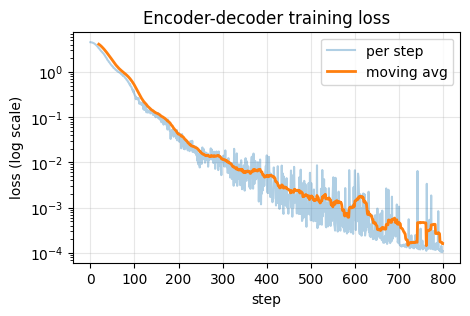

In [17]:
torch.manual_seed(cfg["seed"])
encdec = EncoderDecoder(V).to(device)
print(f"Encoder-decoder parameters: {n_params(encdec):,}   (ln V = {math.log(V):.2f})")
hist_ed, time_ed = train(encdec, train_pairs, encdec_batch, max_steps=ENC_STEPS)
plot_loss(hist_ed, "Encoder-decoder training loss")

### A5. Greedy decoding
At inference time there is no correct answer to feed in. The model **feeds its own predictions back**: encode the source once, then repeatedly decode, take the most likely next character, and append it.

In [18]:
@torch.no_grad()
def greedy_decode_encdec(model, sources, max_len=MAX_TGT - 1):
    model.eval()
    src = torch.tensor([pad_to(encode(s), MAX_SRC) for s in sources], device=device)
    memory, src_mask = model.encode(src)                # encode ONCE
    out = torch.full((len(sources), 1), BOS, dtype=torch.long, device=device)
    for _ in range(max_len):
        # 🎯 TODO 6: run model.decode on `out`, take the argmax of the LAST position (keepdim=True),
        #            and append it to `out` with torch.cat along dim=1
        logits = model.decode(out, memory, src_mask)
        nxt = logits[:, -1].argmax(-1, keepdim=True)
        out = torch.cat([out, nxt], dim=1)
        if (out == EOS).any(1).all():
            break
    model.train()
    return [decode(row[1:].tolist()) for row in out]

In [19]:
# ✅ Check 6: evaluate on validation (seen formats) and held-out (unseen formats)
val_acc_ed, val_pred_ed = exact_match(greedy_decode_encdec, encdec, val_pairs, n=1000)
held_acc_ed, held_pred_ed = exact_match(greedy_decode_encdec, encdec, heldout_pairs, n=1000)
print(f"Encoder-decoder | val exact match {val_acc_ed:.1%} | held-out formats {held_acc_ed:.1%}")
print("per-field accuracy (held-out):", field_accuracy(held_pred_ed, heldout_pairs, cfg))
assert val_acc_ed > 0.5, "Accuracy is very low: re-check TODO 6 (and TODOs 4-5)."
print("✅ Check 6 passed\n\nSome held-out mistakes (if any):")
for p, (s, t) in [(p, st) for p, st in zip(held_pred_ed, heldout_pairs) if p != st[1]][:8]:
    print(f"   {s!r:38s} target {t!r:16s} predicted {p!r}")

Encoder-decoder | val exact match 100.0% | held-out formats 100.0%
per-field accuracy (held-out): {'Y': 1.0, 'M': 1.0, 'D': 1.0}
✅ Check 6 passed

Some held-out mistakes (if any):


### 🔍 Look inside: cross-attention
Each **row** is an output character being written; each **column** is an input character. Bright cells show where the decoder looked.

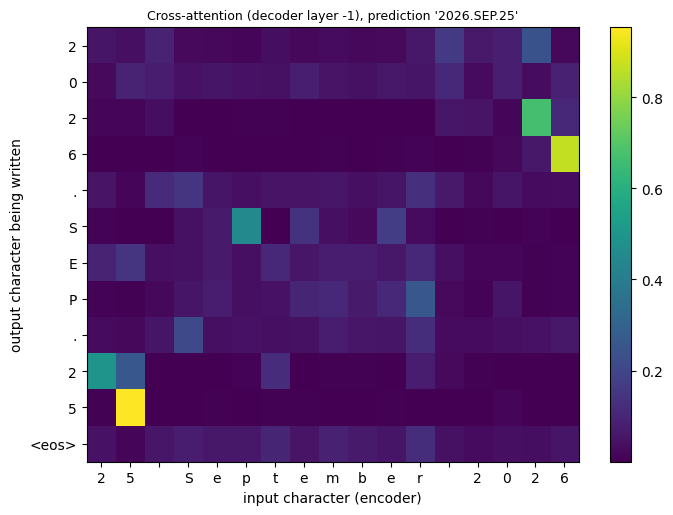

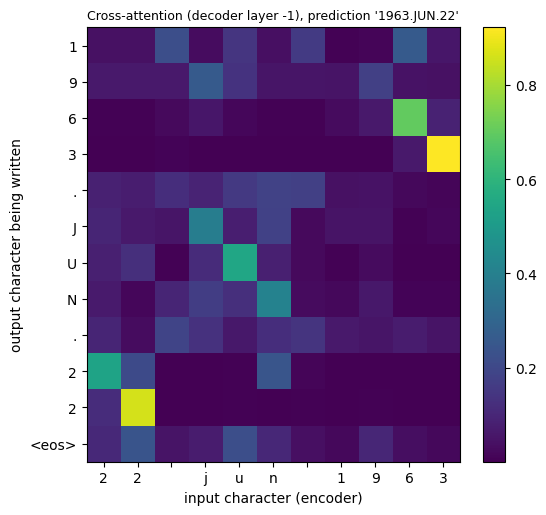

In [20]:
def plot_cross_attention(model, src_text, layer=-1):
    pred = greedy_decode_encdec(model, [src_text])[0]
    src = torch.tensor([pad_to(encode(src_text), MAX_SRC)], device=device)
    dec_in = torch.tensor([[BOS] + encode(pred)], device=device)
    model.eval()
    with torch.no_grad():
        model(src, dec_in)
    model.train()
    w = model.dec[layer].cross_attn.last_weights[0].mean(0)[: len(pred) + 1, : len(src_text)].cpu()
    plt.figure(figsize=(0.32 * len(src_text) + 2.5, 0.32 * (len(pred) + 1) + 1.8))
    plt.imshow(w, cmap="viridis", aspect="auto")
    plt.xticks(range(len(src_text)), list(src_text)); plt.yticks(range(len(pred) + 1), list(pred) + ["<eos>"])
    plt.xlabel("input character (encoder)"); plt.ylabel("output character being written")
    plt.title(f"Cross-attention (decoder layer {layer}), prediction {pred!r}", fontsize=9)
    plt.colorbar(); plt.show()

MY_DATE = "25 September 2026"        # 🤔 try your own birthday too
plot_cross_attention(encdec, MY_DATE)
plot_cross_attention(encdec, heldout_pairs[0][0])

### 🧨 Experiment A (full path): break it on purpose
Three short runs with the same seed and the same number of steps: a **control** (nothing removed), one **without the causal mask**, and one **without the padding mask**. **Predict first:** with the causal mask removed, what happens to the *training loss*? And to the *accuracy*?

In [21]:
EXP_STEPS = ENC_STEPS // 2
broken_results = {}
for name, kwargs in [("control (both masks)", {}), ("no causal mask", dict(use_causal_mask=False)),
                     ("no padding mask", dict(use_padding_mask=False))]:
    torch.manual_seed(cfg["seed"])
    broken = EncoderDecoder(V, **kwargs).to(device)
    print(f"\n=== {name} ===")
    h, _ = train(broken, train_pairs, encdec_batch, max_steps=EXP_STEPS, log_every=EXP_STEPS // 2)
    acc, preds = exact_match(greedy_decode_encdec, broken, val_pairs, n=500)
    broken_results[name] = (float(np.mean(h[-20:])), acc)
    print(f"final training loss {np.mean(h[-20:]):.4f} | val exact match {acc:.1%} | e.g. {preds[:3]}")
print(f"\n{'run':24s}{'final train loss':>18s}{'val exact match':>18s}")
for name, (l, a) in broken_results.items():
    print(f"{name:24s}{l:18.4f}{a:18.1%}")


=== control (both masks) ===
step     0 | loss 4.5257 |   0.0s
step   200 | loss 0.0391 |   4.1s
step   399 | loss 0.0032 |   7.8s
final training loss 0.0040 | val exact match 100.0% | e.g. ['2006.FEB.15', '2001.OCT.11', '1972.DEC.19']

=== no causal mask ===
step     0 | loss 4.5307 |   0.0s
step   200 | loss 0.0031 |   4.6s
step   399 | loss 0.0011 |   8.1s
final training loss 0.0011 | val exact match 0.0% | e.g. ['1911.AUG.11', '1911.APR.11', '1911.AUG.11']

=== no padding mask ===
step     0 | loss 4.5146 |   0.0s
step   200 | loss 0.0845 |   3.6s
step   399 | loss 0.0051 |   8.0s
final training loss 0.0080 | val exact match 98.0% | e.g. ['2006.FEB.15', '2010.OCT.11', '1972.DEC.19']

run                       final train loss   val exact match
control (both masks)                0.0040            100.0%
no causal mask                      0.0011              0.0%
no padding mask                     0.0080             98.0%


## Part B · Decoder-only ⏱ 25 min
The **same task**, with no encoder and no cross-attention. Input and output become one sequence, exactly like prompting a GPT-style model:
```
<bos> 2 5 _ S e p t e m b e r _ 2 0 2 6 <sep> 2 0 2 6 - 0 9 - 2 5 <eos>
```
### B1. The decoder-only block
🤔 Compare with `DecoderLayer`. Which single piece is missing?

In [22]:
# ---------- decoder-only ----------
class DecoderOnlyBlock(nn.Module):
    def __init__(self, d, n_head):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.self_attn, self.ff = MultiHeadAttention(d, n_head), feed_forward(d)
    def forward(self, x, mask):
        # 🎯 TODO 7: your DecoderLayer.forward with the cross-attention line deleted (two sub-layers)
        h = self.ln1(x)
        x = x + self.self_attn(h, h, mask)
        x = x + self.ff(self.ln2(x))
        return x

In [23]:
class DecoderOnly(nn.Module):
    def __init__(self, V, d=128, n_head=4, n_layer=5, max_len=64):
        super().__init__()
        self.tok, self.pos = nn.Embedding(V, d), nn.Embedding(max_len, d)
        self.blocks = nn.ModuleList(DecoderOnlyBlock(d, n_head) for _ in range(n_layer))
        self.ln, self.head = nn.LayerNorm(d), nn.Linear(d, V)
    def forward(self, ids):
        T = ids.size(1)
        mask = make_causal_mask(T, ids.device) & make_padding_mask(ids)
        x = self.tok(ids) + self.pos(torch.arange(T, device=ids.device))
        for b in self.blocks:
            x = b(x, mask)
        return self.head(self.ln(x))

### B2. Packing the sequence and masking the loss
Labels are the sequence shifted by one. We want the model to learn to **produce the answer**, not to predict the messy input, so every position whose next token is still part of the prompt gets label `-100`, which `F.cross_entropy` ignores.
```
input : <bos>   2     5   ...    6   <sep>  2  0 ...   5
label :  -100  -100  -100 ...  -100    2    0  2 ... <eos>
```

In [24]:
MAX_SEQ = MAX_SRC + MAX_TGT
def build_decoder_only_example(src, tgt, answer_only_loss=True):
    """Returns (input_ids, labels) for one pair.
    sequence = [BOS] + src + [SEP] + tgt + [EOS];  input = seq[:-1];  labels = seq[1:]
    If answer_only_loss: labels that predict prompt tokens (src characters or SEP) become -100."""
    seq = [BOS] + encode(src) + [SEP] + encode(tgt) + [EOS]                                    # 🎯 TODO 8a
    inp, labels = seq[:-1], seq[1:]                             # 🎯 TODO 8b
    if answer_only_loss:
        n_prompt = len(src) + 1                          # 🎯 TODO 8c: how many leading labels are prompt tokens?
        labels = [-100] * n_prompt + labels[n_prompt:]
    return inp, labels

In [25]:
# ✅ Checks 7 & 8
_blk = DecoderOnlyBlock(32, 4).eval(); _x = torch.randn(2, 6, 32)
assert _blk(_x, make_causal_mask(6)).shape == (2, 6, 32), "DecoderOnlyBlock: wrong output shape"
assert not any("cross" in n for n, _ in _blk.named_modules()), "a decoder-only block has no cross-attention"
inp, lab = build_decoder_only_example("ab", "c")
a, b, c = encode("abc")
assert inp == [BOS, a, b, SEP, c], f"input wrong: {inp}"
assert lab == [-100, -100, -100, c, EOS], f"masked labels wrong: {lab}"
assert build_decoder_only_example("ab", "c", answer_only_loss=False)[1] == [a, b, SEP, c, EOS]
print("✅ Checks 7 & 8 passed\n")
x, y = build_decoder_only_example(*train_pairs[0])
print("position | input token | label")
for i, (xi, yi) in enumerate(zip(x, y)):
    print(f"{i:8d} | {itos[xi]:>11s} | {'(no loss)' if yi == -100 else itos[yi]}")

✅ Checks 7 & 8 passed

position | input token | label
       0 |       <bos> | (no loss)
       1 |           2 | (no loss)
       2 |           2 | (no loss)
       3 |             | (no loss)
       4 |           M | (no loss)
       5 |           a | (no loss)
       6 |           r | (no loss)
       7 |           c | (no loss)
       8 |           h | (no loss)
       9 |             | (no loss)
      10 |           1 | (no loss)
      11 |           9 | (no loss)
      12 |           6 | (no loss)
      13 |           4 | (no loss)
      14 |       <sep> | 1
      15 |           1 | 9
      16 |           9 | 6
      17 |           6 | 4
      18 |           4 | .
      19 |           . | M
      20 |           M | A
      21 |           A | R
      22 |           R | .
      23 |           . | 2
      24 |           2 | 2
      25 |           2 | <eos>


In [26]:
def deconly_batch(pairs, answer_only_loss=True):
    X, Y = [], []
    for s, t in pairs:
        x, y = build_decoder_only_example(s, t, answer_only_loss)
        X.append(pad_to(x, MAX_SEQ))
        Y.append(y[:MAX_SEQ] + [-100] * (MAX_SEQ - len(y)))
    return torch.tensor(X, device=device), torch.tensor(Y, device=device)

### B3. Prompted generation
The prompt is `<bos> src <sep>`; the model then writes the answer one character at a time. Prompts of equal length are batched together, so no padding is needed.

In [28]:
@torch.no_grad()
def greedy_decode_deconly(model, sources, max_len=MAX_TGT - 1):
    """Prompt with [BOS] src [SEP] and generate until EOS.
    Prompts of equal length are batched together, so no padding is needed."""
    model.eval()
    outs = [None] * len(sources)
    groups = {}
    for i, s in enumerate(sources):
        groups.setdefault(len(s), []).append(i)
    for idx in groups.values():
        # 🎯 TODO 9a: one prompt per source in this group: [BOS] + encode(src) + [SEP]
        ids = torch.tensor([[BOS] + encode(sources[i]) + [SEP] for i in idx], device=device)
        start = ids.size(1)
        for _ in range(max_len):
            # 🎯 TODO 9b: run the model on ALL of ids, argmax of the last position (keepdim=True), append
            nxt =  model(ids)[:, -1].argmax(-1, keepdim=True)
            ids = torch.cat([ids, nxt], dim=1)
            if (ids[:, start:] == EOS).any(1).all():
                break
        for j, i in enumerate(idx):
            outs[i] = decode(ids[j, start:].tolist())
    model.train()
    return outs

### Train the decoder-only model
🤔 **Think:** will it need more or fewer steps than the encoder–decoder to reach the same accuracy? Will each step be faster or slower? Why?

Decoder-only parameters: 1,018,569
step     0 | loss 4.4473 |   0.1s
step   100 | loss 0.7332 |   3.0s
step   200 | loss 0.0457 |   6.4s
step   300 | loss 0.0156 |   9.4s
step   400 | loss 0.0066 |  12.3s
step   500 | loss 0.0035 |  15.3s
step   600 | loss 0.0016 |  18.2s
step   700 | loss 0.0010 |  21.3s
step   800 | loss 0.0001 |  24.2s
step   900 | loss 0.0022 |  27.2s
step  1000 | loss 0.0001 |  30.1s
step  1100 | loss 0.0001 |  33.3s
step  1200 | loss 0.0000 |  36.2s
step  1300 | loss 0.0001 |  39.2s
step  1400 | loss 0.0000 |  42.1s
step  1499 | loss 0.0000 |  45.7s


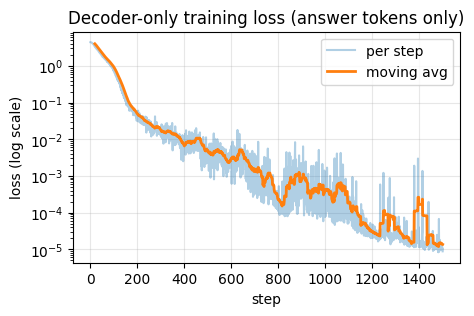

In [29]:
torch.manual_seed(cfg["seed"])
deconly = DecoderOnly(V).to(device)
print(f"Decoder-only parameters: {n_params(deconly):,}")
hist_do, time_do = train(deconly, train_pairs, deconly_batch, max_steps=DEC_STEPS)
plot_loss(hist_do, "Decoder-only training loss (answer tokens only)")

In [30]:
# ✅ Check 9: evaluate
val_acc_do, val_pred_do = exact_match(greedy_decode_deconly, deconly, val_pairs, n=1000)
held_acc_do, held_pred_do = exact_match(greedy_decode_deconly, deconly, heldout_pairs, n=1000)
print(f"Decoder-only | val exact match {val_acc_do:.1%} | held-out formats {held_acc_do:.1%}")
print("per-field accuracy (held-out):", field_accuracy(held_pred_do, heldout_pairs, cfg))
assert val_acc_do > 0.5, "Accuracy is very low: re-check TODOs 7-9."
print("✅ Check 9 passed\n\nSome held-out mistakes (if any):")
for p, (s, t) in [(p, st) for p, st in zip(held_pred_do, heldout_pairs) if p != st[1]][:8]:
    print(f"   {s!r:38s} target {t!r:16s} predicted {p!r}")

Decoder-only | val exact match 100.0% | held-out formats 100.0%
per-field accuracy (held-out): {'Y': 1.0, 'M': 1.0, 'D': 1.0}
✅ Check 9 passed

Some held-out mistakes (if any):


### 🔍 Look inside: where do the answer characters look?
There is no cross-attention here. Rows are the positions that predict each answer character; columns are **all** earlier positions, prompt included.

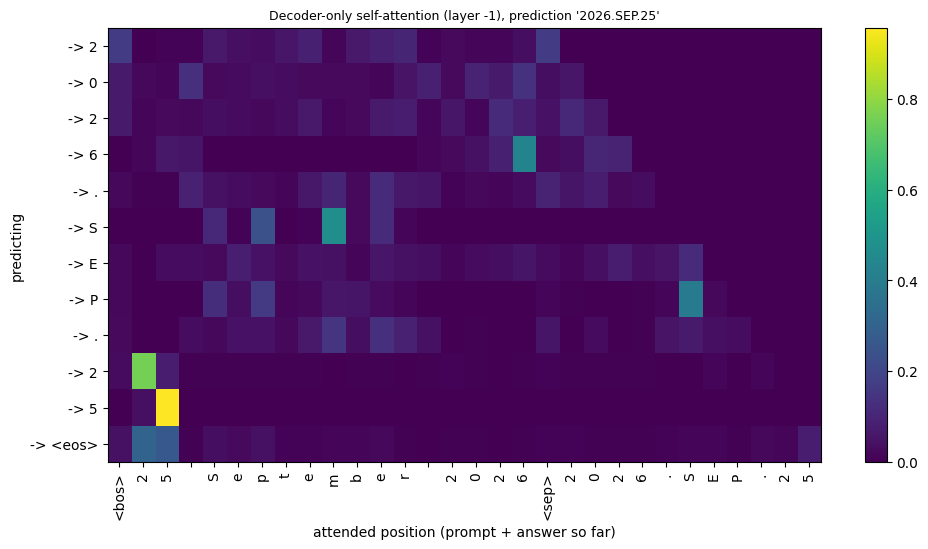

In [31]:
def plot_deconly_attention(model, src_text, layer=-1):
    pred = greedy_decode_deconly(model, [src_text])[0]
    seq = [BOS] + encode(src_text) + [SEP] + encode(pred)
    model.eval()
    with torch.no_grad():
        model(torch.tensor([seq], device=device))
    model.train()
    start = len(src_text) + 1                      # index of <sep>: it predicts the first answer character
    w = model.blocks[layer].self_attn.last_weights[0].mean(0)[start:, :].cpu()
    labels = ["<bos>"] + list(src_text) + ["<sep>"] + list(pred)
    plt.figure(figsize=(0.3 * len(labels) + 2.5, 0.32 * w.size(0) + 1.8))
    plt.imshow(w, cmap="viridis", aspect="auto")
    plt.xticks(range(len(labels)), labels, rotation=90)
    plt.yticks(range(w.size(0)), [f"-> {ch}" for ch in list(pred) + ["<eos>"]])
    plt.xlabel("attended position (prompt + answer so far)"); plt.ylabel("predicting")
    plt.title(f"Decoder-only self-attention (layer {layer}), prediction {pred!r}", fontsize=9)
    plt.colorbar(); plt.show()

plot_deconly_attention(deconly, MY_DATE)

### 🧨 Experiment B (full path): answer-only loss vs loss on every token
With `answer_only_loss=False` the model must also predict the messy **input** characters, which is what pre-training does. With `True` it only learns to produce the answer, which is what supervised fine-tuning (SFT) does. **Predict:** which has the lower training loss? Which is more accurate?

In [32]:
torch.manual_seed(cfg["seed"])
full = DecoderOnly(V).to(device)
hist_full, _ = train(full, train_pairs, lambda p: deconly_batch(p, answer_only_loss=False),
                     max_steps=DEC_STEPS, log_every=DEC_STEPS // 3)
acc_full, _ = exact_match(greedy_decode_deconly, full, val_pairs, n=1000)
held_full, _ = exact_match(greedy_decode_deconly, full, heldout_pairs, n=1000)
print(f"\n                  answer-only   every token")
print(f"final train loss  {np.mean(hist_do[-50:]):11.4f}   {np.mean(hist_full[-50:]):11.4f}")
print(f"val exact match   {val_acc_do:11.1%}   {acc_full:11.1%}")
print(f"held-out match    {held_acc_do:11.1%}   {held_full:11.1%}")

step     0 | loss 4.4272 |   0.0s
step   500 | loss 0.5831 |  14.7s
step  1000 | loss 0.5672 |  29.6s
step  1499 | loss 0.5635 |  44.6s

                  answer-only   every token
final train loss       0.0000        0.5622
val exact match        100.0%        100.0%
held-out match         100.0%        100.0%


## Part C · Head-to-head comparison ⏱ 15 min

In [33]:
ex_src, ex_tgt = val_pairs[0]
rows = [
    ("Parameters", f"{n_params(encdec):,}", f"{n_params(deconly):,}"),
    ("Training steps", ENC_STEPS, DEC_STEPS),
    ("Training time (s)", f"{time_ed:.0f}", f"{time_do:.0f}"),
    ("Time per step (ms)", f"{1000 * time_ed / ENC_STEPS:.0f}", f"{1000 * time_do / DEC_STEPS:.0f}"),
    ("Val exact match", f"{val_acc_ed:.1%}", f"{val_acc_do:.1%}"),
    ("Held-out exact match", f"{held_acc_ed:.1%}", f"{held_acc_do:.1%}"),
    ("Positions for one example", f"{len(ex_src)} enc + {len(ex_tgt) + 1} dec", f"{len(ex_src) + len(ex_tgt) + 2} in one sequence"),
    ("Input reaches output via", "cross-attention", "causal self-attention"),
]
print(f"{'':30s}{'Encoder-decoder':>26s}{'Decoder-only':>28s}")
for r in rows:
    print(f"{r[0]:30s}{str(r[1]):>26s}{str(r[2]):>28s}")

                                         Encoder-decoder                Decoder-only
Parameters                                       953,161                   1,018,569
Training steps                                       800                        1500
Training time (s)                                     18                          46
Time per step (ms)                                    23                          30
Val exact match                                   100.0%                      100.0%
Held-out exact match                              100.0%                      100.0%
Positions for one example                16 enc + 12 dec          29 in one sequence
Input reaches output via                 cross-attention       causal self-attention


### Save your submission file
This writes `submission.json`. Download it (📁 panel on the left) and submit it with this notebook and your report.

In [34]:
submission = {
    "student_id": cfg["student_id"], "fingerprint": FP,
    "config": {k: cfg[k] for k in ["order", "sep", "month_style", "heldout_combos"]},
    "results": {"encdec_val": val_acc_ed, "encdec_heldout": held_acc_ed,
                "deconly_val": val_acc_do, "deconly_heldout": held_acc_do,
                "encdec_params": n_params(encdec), "deconly_params": n_params(deconly),
                "encdec_time": time_ed, "deconly_time": time_do, "device": device},
    "heldout_predictions": {"encdec": held_pred_ed[:200], "deconly": held_pred_do[:200]},
}
with open("submission.json", "w") as f:
    json.dump(submission, f, indent=1)
print("saved submission.json | fingerprint", FP)

saved submission.json | fingerprint 53ddece0fd2f


## 🎉 Done
Now answer the report questions in the lab manual using **your** numbers and **your** plots.

**Stretch goals (optional)**
1. Train the decoder-only model for the same number of *seconds* as the encoder–decoder. Which wins now?
2. Change `n_head` to 1 and to 8 and compare the attention maps.
3. Plot `plot_cross_attention(encdec, MY_DATE, layer=0)` and compare the first and last decoder layers.
4. Add a KV-cache to `greedy_decode_deconly` so each step only processes the newest token. Measure the speed-up.